In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SuperFOVi', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="block9_phantom"

In [3]:
slices = 500
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),
    2: ('bone marrow', 0.370, 0.05, 0),
    3: ('liver', 0.8, 0.04, 0),
    4: ('white matter', 1.0, 0.08, 0),
    5: ('myocardium', 1.150, 0.045, 0),
    6: ('vessels', 1.2, 0.05, 0),   
    7: ('gray matter', 1.3, 0.110, 0),
    8: ('muscle', 1.4, 0.030, 0),
    9: ('CSF', 4.0, 1.0, 0)
}

dataset = mssfp.generate_ssfp_dataset(
    phantom_type='block', 
    slices=slices, 
    shape=128, 
    ids=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    tissues = tissue_parameters,
    npcs=4, 
    f=500, 
    alpha=np.deg2rad(40), 
    sigma=0.001, 
    useRotate=True, 
    useDeform=True,
    rotation=90,
    fn_offset=250
)

Generating phantom...
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (500, 128, 128, 4)



===== Running experiment: BandRemoval:4 =====
Model path: D:/DeepSSFP/block9_phantom_bandremoval_4
Dataset path: D:/DeepSSFP/block9_phantom_dataset.npy
Saved dataset found. Loading from file: D:/DeepSSFP/block9_phantom_dataset.npy
Data shape: (500, 128, 128, 4)
Training data shape: (400, 128, 128, 8), (400, 128, 128, 2)
Input scaler stats: mean=-0.0004, std=0.0755
Output scaler stats: mean=-0.0006, std=0.0607
Selected indices: [11 56 85]
Figure size: (10, 6)


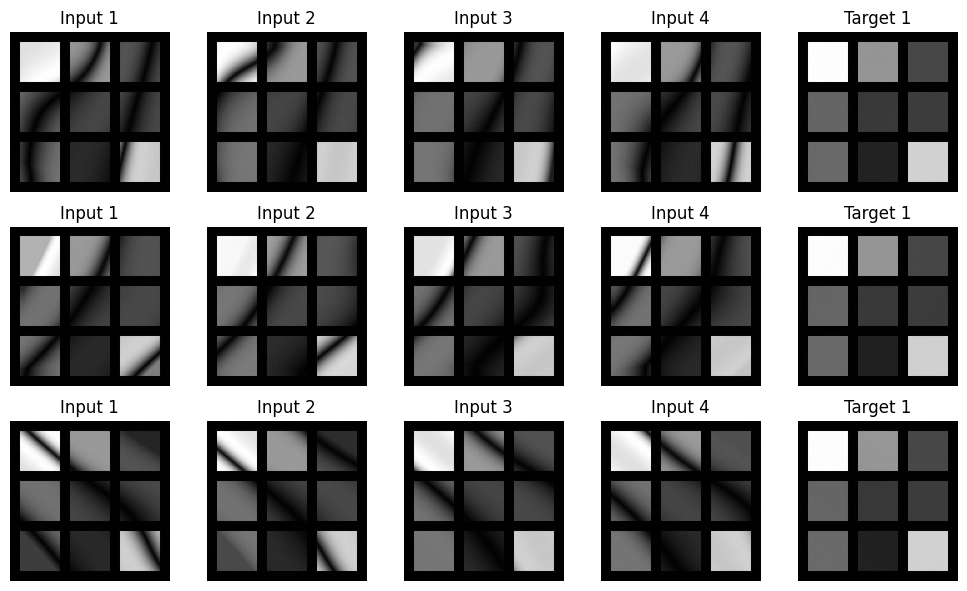

2025-03-26 21:59:09,883 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block9_phantom_bandremoval_4
2025-03-26 21:59:09,890 - DeepSSFP - INFO - Training DataSet: (400, 128, 128, 8) | (400, 128, 128, 2)
2025-03-26 21:59:09,890 - DeepSSFP - INFO - Test DataSet: (100, 128, 128, 8) | (100, 128, 128, 2)



Training model...


2025-03-26 21:59:10,441 - DeepSSFP - INFO - Loading existing model from D:/DeepSSFP/block9_phantom_bandremoval_4.keras
2025-03-26 21:59:12,615 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block9_phantom_bandremoval_4_history.npz
2025-03-26 21:59:12,638 - DeepSSFP - INFO - Continuing training from epoch 92


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-03-26 22:07:32,238 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block9_phantom_bandremoval_4.keras


4/4 [==============================] - 1s 16ms/step - loss: 6.5869e-04 - mean_absolute_error: 0.0182


2025-03-26 22:07:33,868 - DeepSSFP - INFO - Training Complete. Loss: 0.0007, MAE: 0.0182
2025-03-26 22:07:33,868 - DeepSSFP - INFO - Time Elapsed: 501.23 seconds
2025-03-26 22:07:34,960 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block9_phantom_bandremoval_4_training_history.png


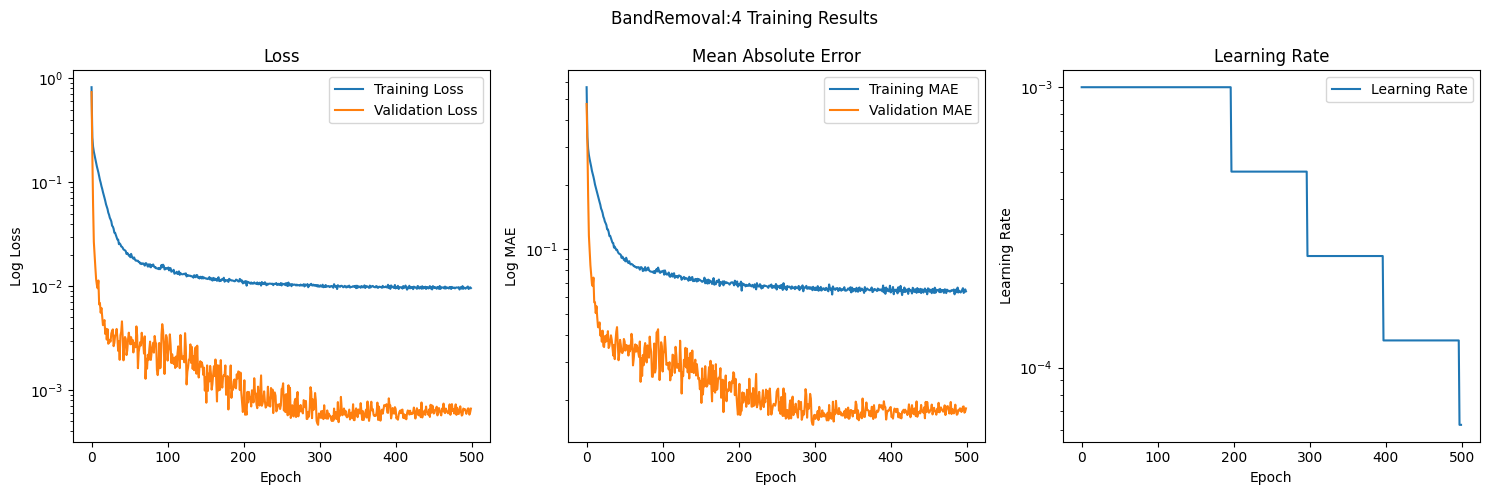

2025-03-26 22:08:00,216 - DeepSSFP - INFO - Making predictions on data with shape (100, 128, 128, 8)
2025-03-26 22:08:00,682 - DeepSSFP - INFO - Predictions complete. Output shape: (100, 128, 128, 2)


Selected indices: [64 81]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/block9_phantom_bandremoval_4_prediction_results.png


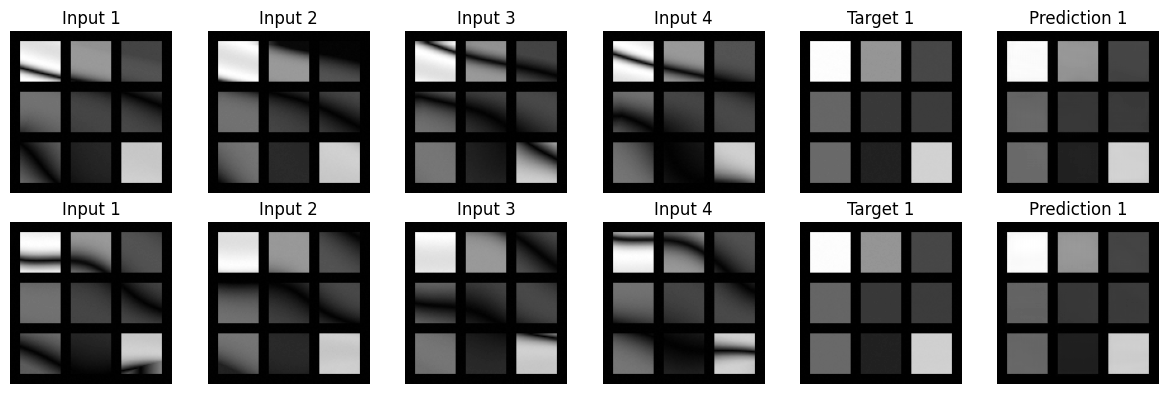

Target shape: (100, 128, 128), Prediction shape: (100, 128, 128)


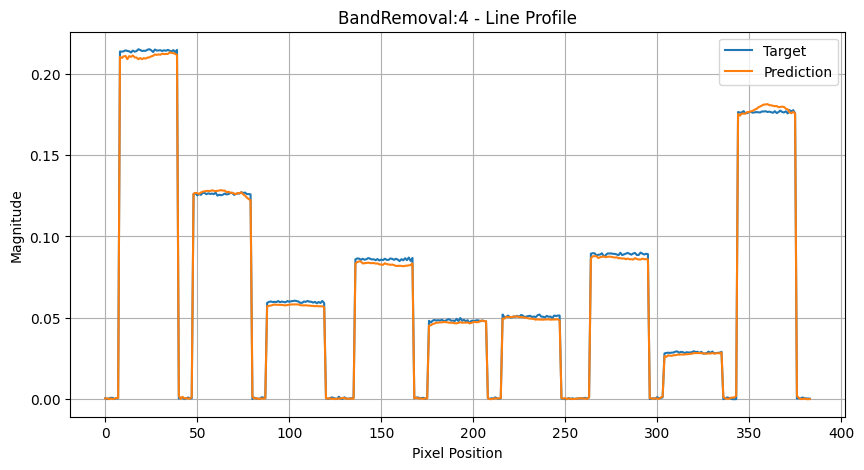


Evaluating band reduction...
Target shape: (100, 128, 128)
Prediction shape: (100, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
IDs to plot: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
Training history plot saved to D:/DeepSSFP/block9_phantom_bandremoval_4_band_metrics_scatter


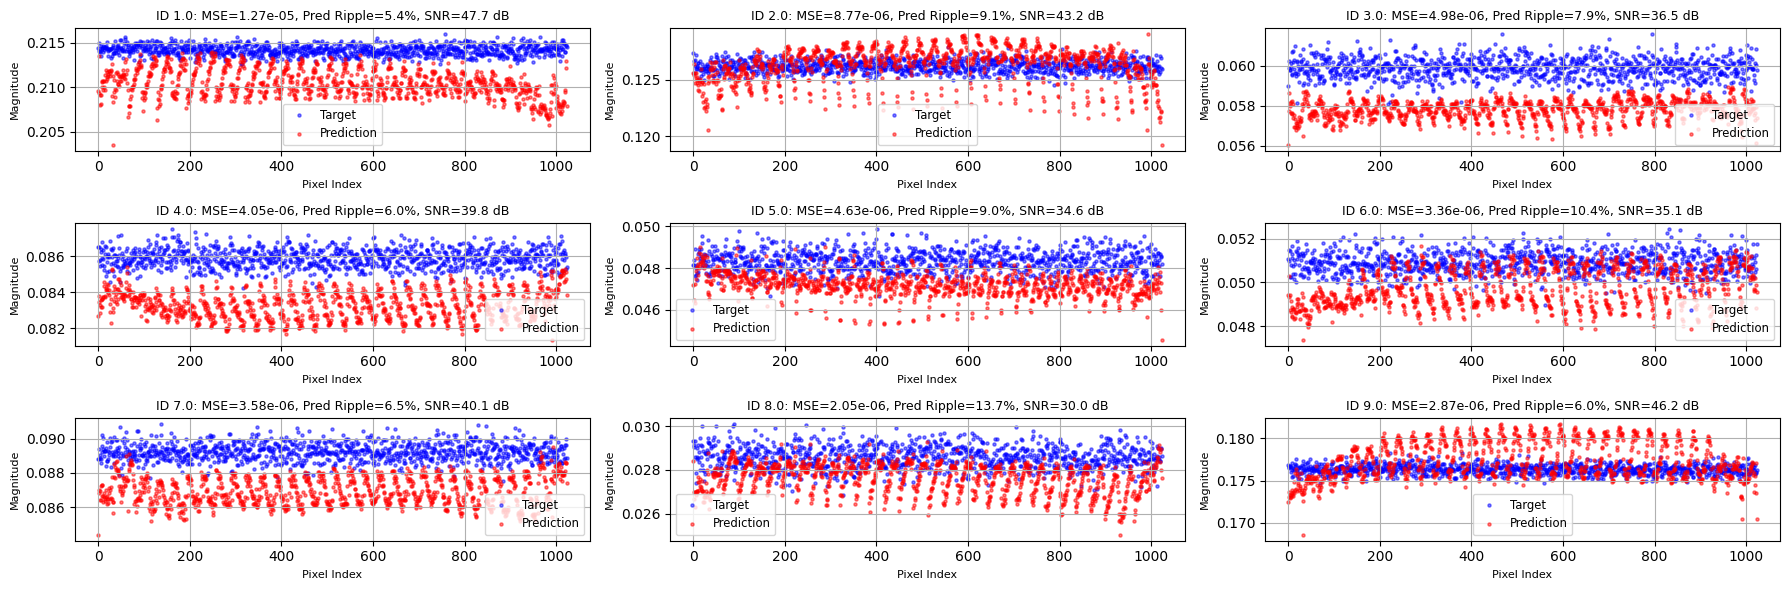

Training history plot saved to D:/DeepSSFP/block9_phantom_bandremoval_4_band_metrics


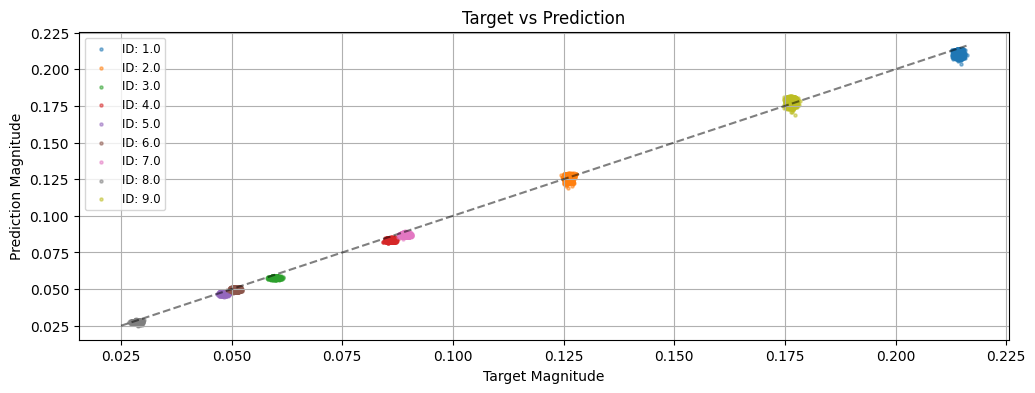


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=1.27e-05, MAE=3.00e-03, Pred Min=0.2037, Pred Max=0.2152, Pred Ripple=5.44%, Pred SNR=47.7 dB, Target Min=0.2124, Target Max=0.2163, Target Ripple=1.79%, Target SNR=49.5 dB, Samples=100, Pixels=1024
ID 2.0: MSE=8.77e-06, MAE=2.18e-03, Pred Min=0.1172, Pred Max=0.1285, Pred Ripple=9.06%, Pred SNR=43.2 dB, Target Min=0.1246, Target Max=0.1280, Target Ripple=2.71%, Target SNR=44.9 dB, Samples=100, Pixels=1024
ID 3.0: MSE=4.98e-06, MAE=1.95e-03, Pred Min=0.0558, Pred Max=0.0604, Pred Ripple=7.85%, Pred SNR=36.5 dB, Target Min=0.0582, Target Max=0.0615, Target Ripple=5.55%, Target SNR=38.4 dB, Samples=100, Pixels=1024
ID 4.0: MSE=4.05e-06, MAE=1.70e-03, Pred Min=0.0819, Pred Max=0.0870, Pred Ripple=6.04%, Pred SNR=39.8 dB, Target Min=0.0842, Target Max=0.0876, Target Ripple=3.94%, Target SNR=41.5 dB, Samples=100, Pixels=1024
ID 5.0: MSE=4.63e-06, MAE=1.83e-03, Pred Min=0.0445, Pred Max=0.0487, Pred Ripple=9.00%, Pred SNR=34.6

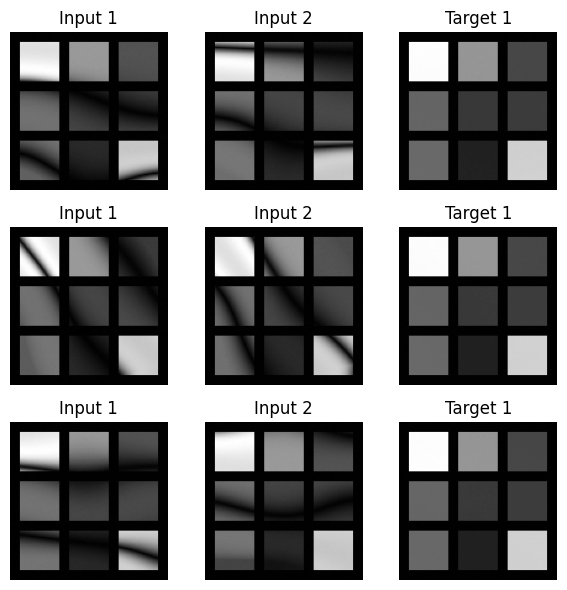

2025-03-26 22:08:32,417 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block9_phantom_bandremoval_2
2025-03-26 22:08:32,417 - DeepSSFP - INFO - Training DataSet: (400, 128, 128, 4) | (400, 128, 128, 2)
2025-03-26 22:08:32,418 - DeepSSFP - INFO - Test DataSet: (100, 128, 128, 4) | (100, 128, 128, 2)
2025-03-26 22:08:32,420 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x4→2



Training model...


2025-03-26 22:08:32,678 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-03-26 22:16:36,994 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block9_phantom_bandremoval_2.keras


4/4 [==============================] - 0s 14ms/step - loss: 0.0011 - mean_absolute_error: 0.0175


2025-03-26 22:16:37,732 - DeepSSFP - INFO - Training Complete. Loss: 0.0011, MAE: 0.0175
2025-03-26 22:16:37,733 - DeepSSFP - INFO - Time Elapsed: 485.04 seconds
2025-03-26 22:16:38,960 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block9_phantom_bandremoval_2_training_history.png


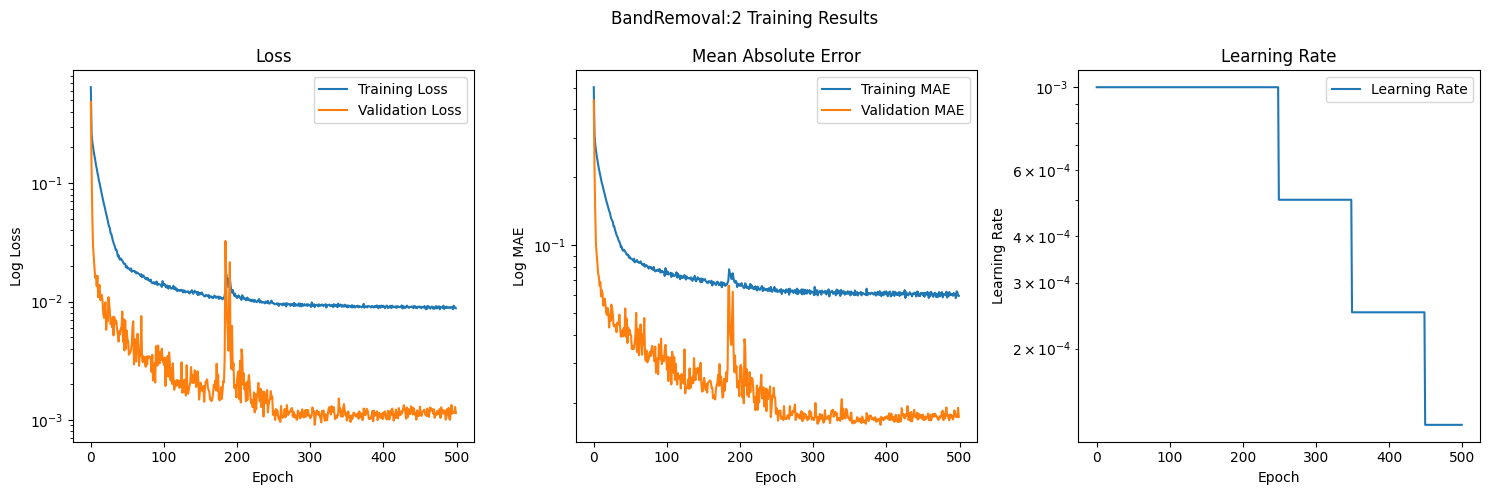

2025-03-26 22:17:04,461 - DeepSSFP - INFO - Making predictions on data with shape (100, 128, 128, 4)
2025-03-26 22:17:04,910 - DeepSSFP - INFO - Predictions complete. Output shape: (100, 128, 128, 2)


Selected indices: [36 37]
Figure size: (8, 4)
Image visualization saved to D:/DeepSSFP/block9_phantom_bandremoval_2_prediction_results.png


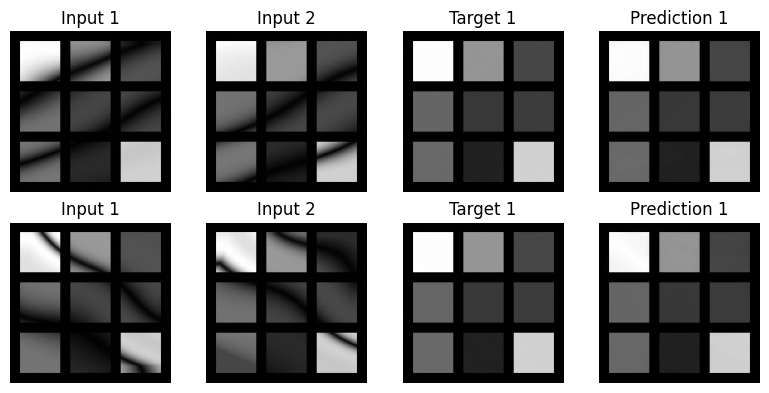

Target shape: (100, 128, 128), Prediction shape: (100, 128, 128)


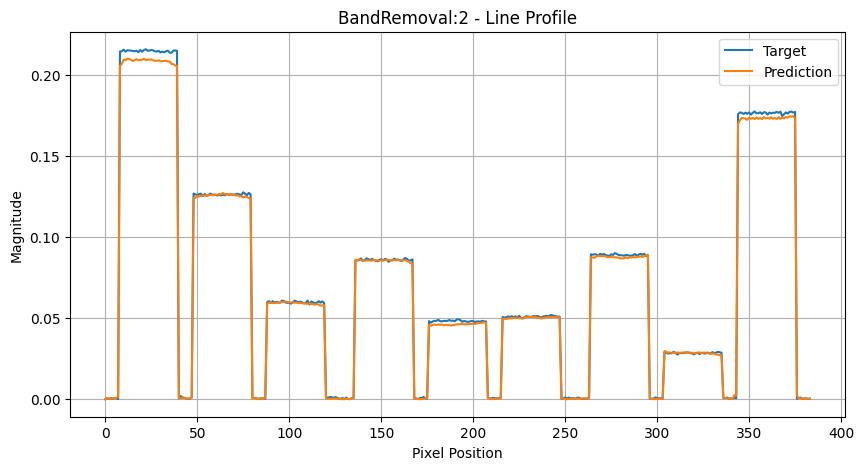


Evaluating band reduction...
Target shape: (100, 128, 128)
Prediction shape: (100, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
IDs to plot: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
Training history plot saved to D:/DeepSSFP/block9_phantom_bandremoval_2_band_metrics_scatter


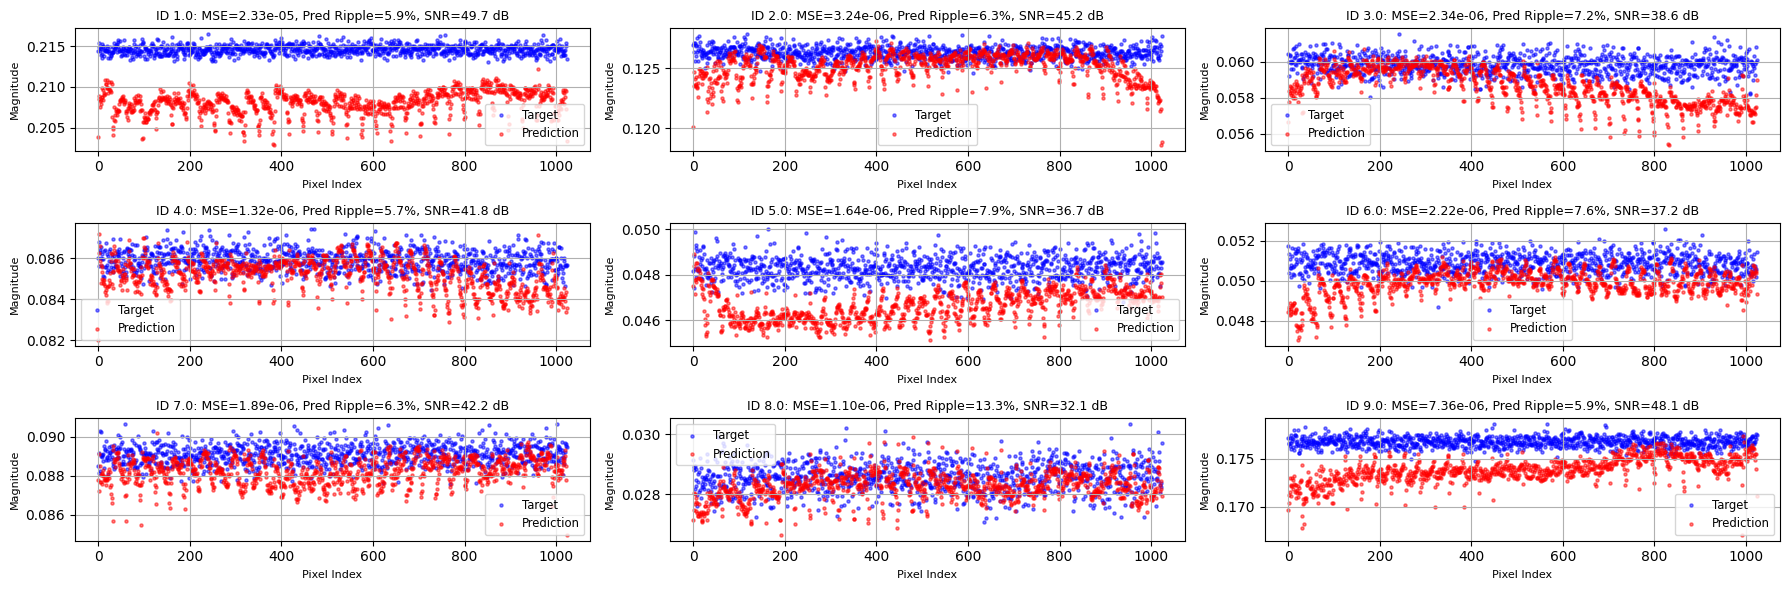

Training history plot saved to D:/DeepSSFP/block9_phantom_bandremoval_2_band_metrics


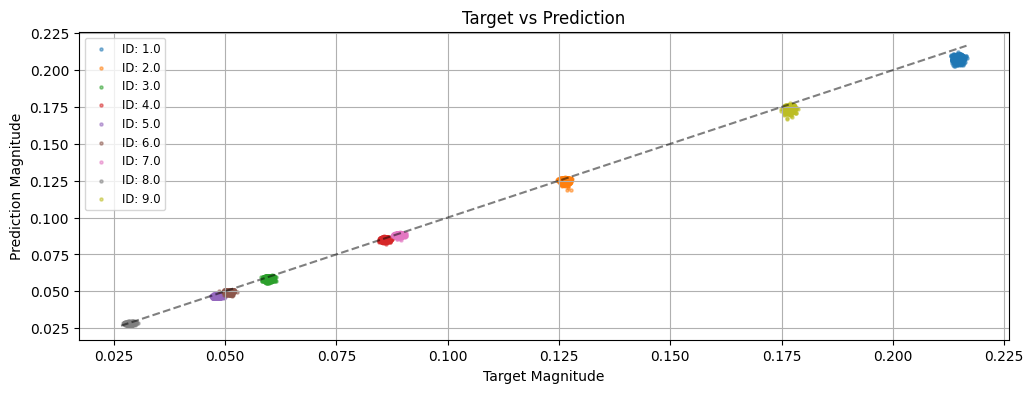


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=2.33e-05, MAE=4.34e-03, Pred Min=0.2021, Pred Max=0.2144, Pred Ripple=5.85%, Pred SNR=49.7 dB, Target Min=0.2124, Target Max=0.2163, Target Ripple=1.80%, Target SNR=49.5 dB, Samples=100, Pixels=1024
ID 2.0: MSE=3.24e-06, MAE=1.47e-03, Pred Min=0.1198, Pred Max=0.1277, Pred Ripple=6.30%, Pred SNR=45.2 dB, Target Min=0.1246, Target Max=0.1281, Target Ripple=2.73%, Target SNR=44.9 dB, Samples=100, Pixels=1024
ID 3.0: MSE=2.34e-06, MAE=1.28e-03, Pred Min=0.0562, Pred Max=0.0604, Pred Ripple=7.19%, Pred SNR=38.6 dB, Target Min=0.0582, Target Max=0.0615, Target Ripple=5.50%, Target SNR=38.4 dB, Samples=100, Pixels=1024
ID 4.0: MSE=1.32e-06, MAE=9.09e-04, Pred Min=0.0822, Pred Max=0.0871, Pred Ripple=5.66%, Pred SNR=41.8 dB, Target Min=0.0842, Target Max=0.0876, Target Ripple=3.93%, Target SNR=41.5 dB, Samples=100, Pixels=1024
ID 5.0: MSE=1.64e-06, MAE=1.06e-03, Pred Min=0.0454, Pred Max=0.0491, Pred Ripple=7.88%, Pred SNR=36.7

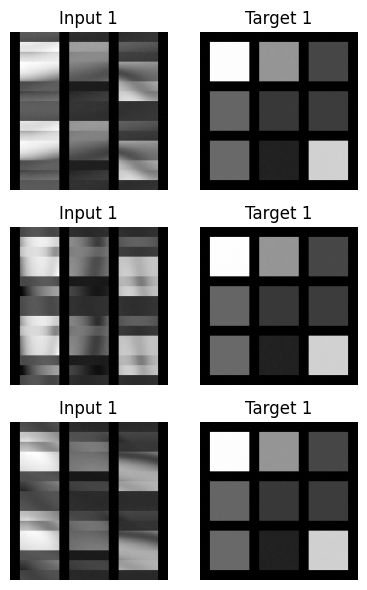

2025-03-26 22:17:38,179 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block9_phantom_superfov
2025-03-26 22:17:38,179 - DeepSSFP - INFO - Training DataSet: (400, 128, 128, 2) | (400, 128, 128, 2)
2025-03-26 22:17:38,180 - DeepSSFP - INFO - Test DataSet: (100, 128, 128, 2) | (100, 128, 128, 2)
2025-03-26 22:17:38,182 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x2→2



Training model...


2025-03-26 22:17:38,507 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 2) 0                                            
__________________________________________________________________________________________________
conv2d_19 (Conv2D)              (None, 128, 128, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_20 (Conv2D)              (None, 128, 128, 32) 9248        conv2d_19[0][0]                  
__________________________________________________________________________________________________
batch_normalization_9 (BatchNor (None, 128, 128, 32) 128         conv2d_20[0][0]                  
_______________________________________________________________________________________________

2025-03-26 22:25:25,670 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block9_phantom_superfov.keras


4/4 [==============================] - 0s 14ms/step - loss: 0.0219 - mean_absolute_error: 0.0383


2025-03-26 22:25:26,416 - DeepSSFP - INFO - Training Complete. Loss: 0.0219, MAE: 0.0383
2025-03-26 22:25:26,417 - DeepSSFP - INFO - Time Elapsed: 467.90 seconds
2025-03-26 22:25:27,477 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block9_phantom_superfov_training_history.png


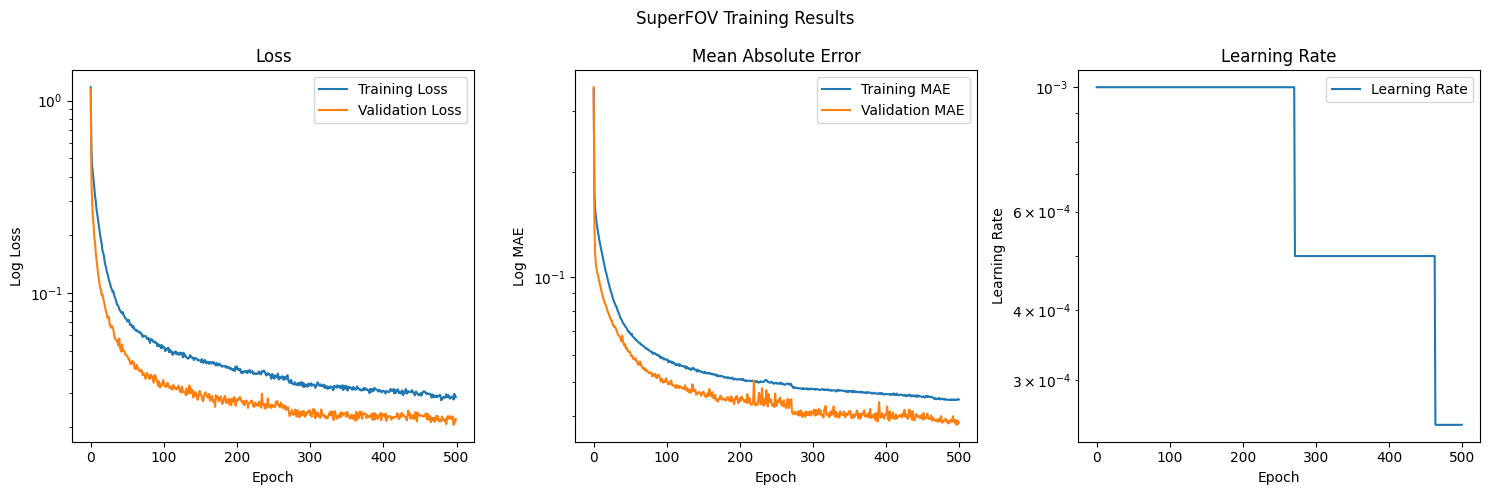

2025-03-26 22:25:53,133 - DeepSSFP - INFO - Making predictions on data with shape (100, 128, 128, 2)
2025-03-26 22:25:53,541 - DeepSSFP - INFO - Predictions complete. Output shape: (100, 128, 128, 2)


Selected indices: [ 0 72]
Figure size: (6, 4)
Image visualization saved to D:/DeepSSFP/block9_phantom_superfov_prediction_results.png


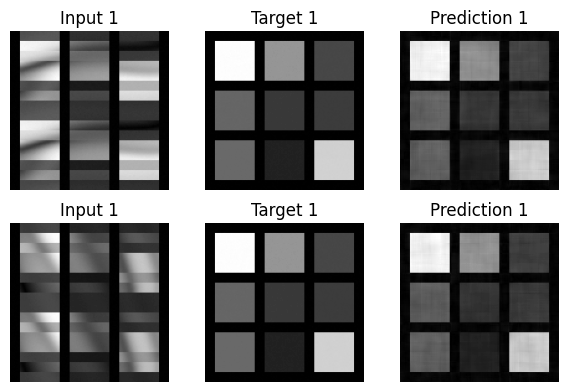

Target shape: (100, 128, 128), Prediction shape: (100, 128, 128)


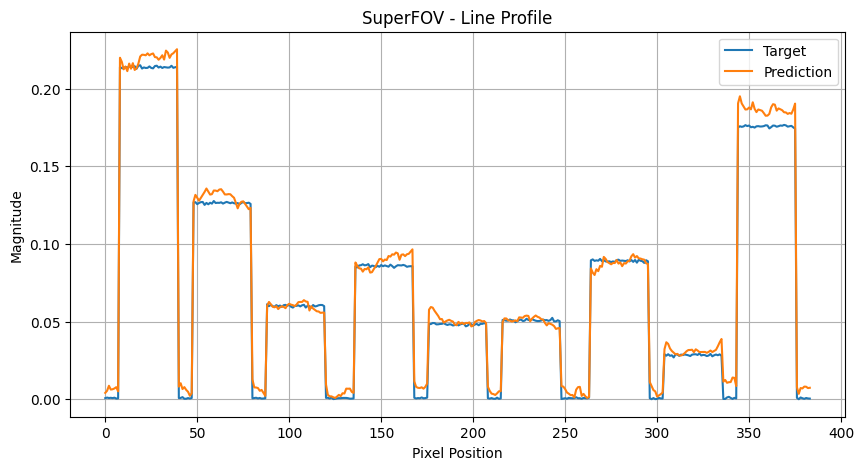


Evaluating band reduction...
Target shape: (100, 128, 128)
Prediction shape: (100, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
IDs to plot: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
Training history plot saved to D:/DeepSSFP/block9_phantom_superfov_band_metrics_scatter


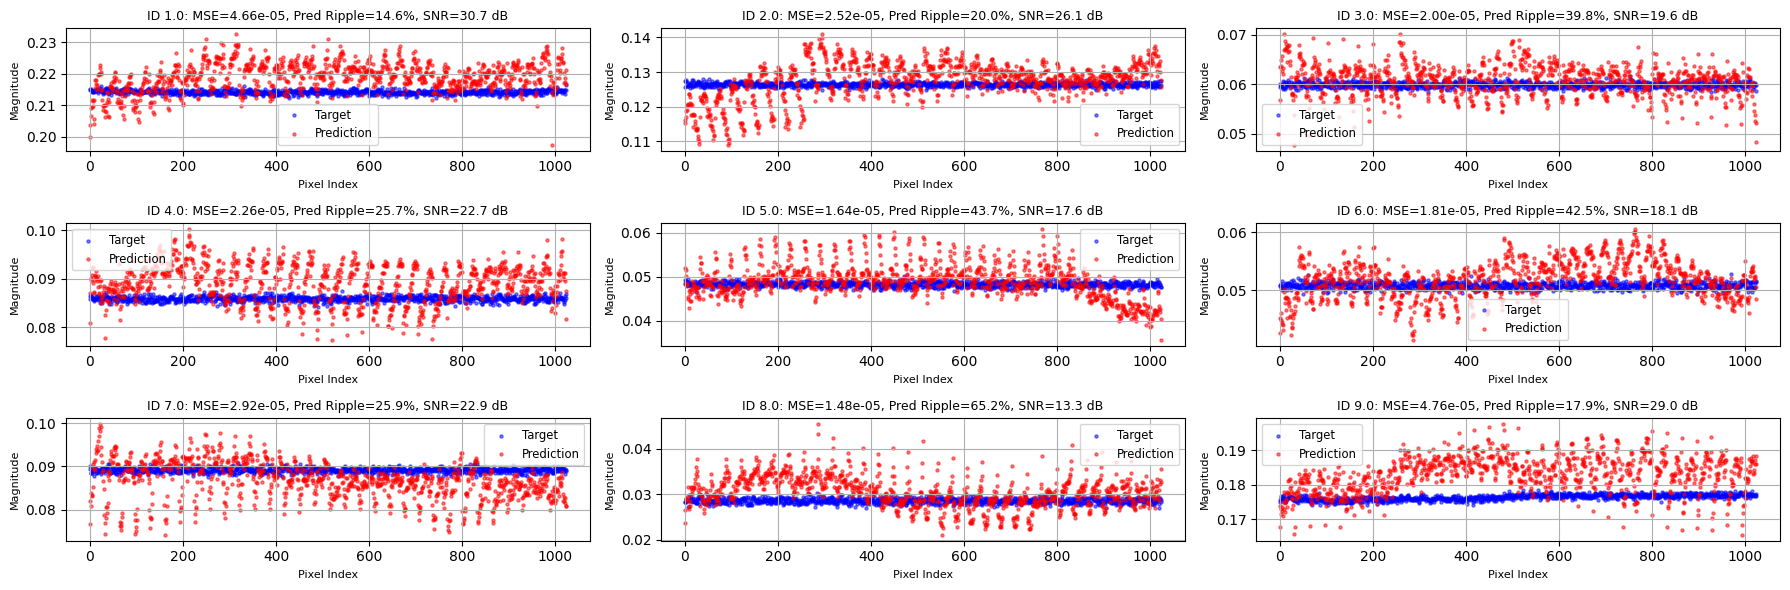

Training history plot saved to D:/DeepSSFP/block9_phantom_superfov_band_metrics


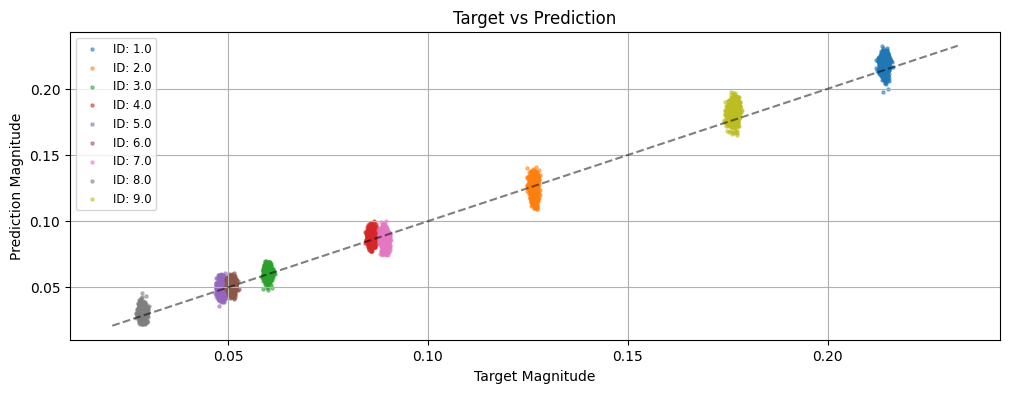


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=4.66e-05, MAE=5.29e-03, Pred Min=0.1976, Pred Max=0.2288, Pred Ripple=14.59%, Pred SNR=30.7 dB, Target Min=0.2124, Target Max=0.2162, Target Ripple=1.80%, Target SNR=49.5 dB, Samples=100, Pixels=1024
ID 2.0: MSE=2.52e-05, MAE=3.88e-03, Pred Min=0.1118, Pred Max=0.1368, Pred Ripple=20.04%, Pred SNR=26.1 dB, Target Min=0.1246, Target Max=0.1281, Target Ripple=2.72%, Target SNR=44.9 dB, Samples=100, Pixels=1024
ID 3.0: MSE=2.00e-05, MAE=3.50e-03, Pred Min=0.0462, Pred Max=0.0697, Pred Ripple=39.82%, Pred SNR=19.6 dB, Target Min=0.0582, Target Max=0.0616, Target Ripple=5.60%, Target SNR=38.4 dB, Samples=100, Pixels=1024
ID 4.0: MSE=2.26e-05, MAE=3.73e-03, Pred Min=0.0731, Pred Max=0.0947, Pred Ripple=25.69%, Pred SNR=22.7 dB, Target Min=0.0842, Target Max=0.0875, Target Ripple=3.87%, Target SNR=41.5 dB, Samples=100, Pixels=1024
ID 5.0: MSE=1.64e-05, MAE=3.17e-03, Pred Min=0.0366, Pred Max=0.0572, Pred Ripple=43.69%, Pred SNR

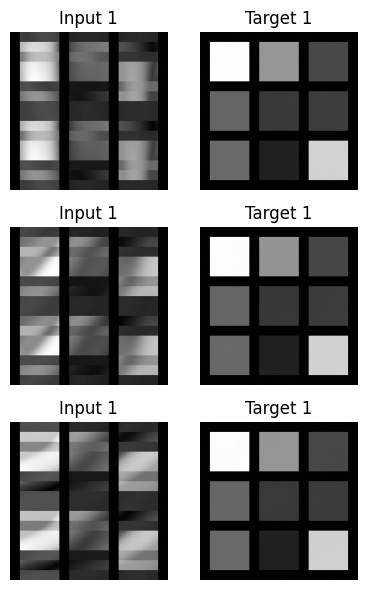

2025-03-26 22:26:26,841 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block9_phantom_superfovi
2025-03-26 22:26:26,842 - DeepSSFP - INFO - Training DataSet: (400, 128, 128, 2) | (400, 128, 128, 2)
2025-03-26 22:26:26,842 - DeepSSFP - INFO - Test DataSet: (100, 128, 128, 2) | (100, 128, 128, 2)
2025-03-26 22:26:26,844 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x2→2



Training model...


2025-03-26 22:26:27,130 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 2) 0                                            
__________________________________________________________________________________________________
conv2d_38 (Conv2D)              (None, 128, 128, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_39 (Conv2D)              (None, 128, 128, 32) 9248        conv2d_38[0][0]                  
__________________________________________________________________________________________________
batch_normalization_18 (BatchNo (None, 128, 128, 32) 128         conv2d_39[0][0]                  
_______________________________________________________________________________________________

2025-03-26 22:34:08,945 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block9_phantom_superfovi.keras


4/4 [==============================] - 0s 15ms/step - loss: 0.0039 - mean_absolute_error: 0.0325


2025-03-26 22:34:09,775 - DeepSSFP - INFO - Training Complete. Loss: 0.0039, MAE: 0.0325
2025-03-26 22:34:09,776 - DeepSSFP - INFO - Time Elapsed: 462.63 seconds
2025-03-26 22:34:10,827 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block9_phantom_superfovi_training_history.png


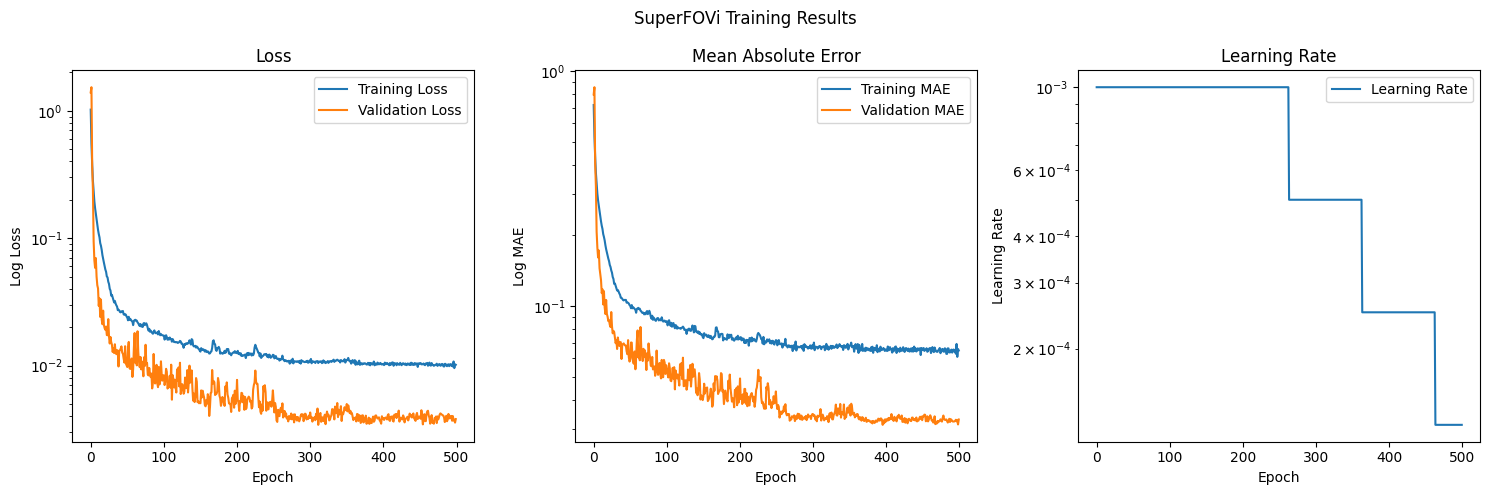

2025-03-26 22:34:39,234 - DeepSSFP - INFO - Making predictions on data with shape (100, 128, 128, 2)
2025-03-26 22:34:39,573 - DeepSSFP - INFO - Predictions complete. Output shape: (100, 128, 128, 2)


Selected indices: [43 81]
Figure size: (6, 4)
Image visualization saved to D:/DeepSSFP/block9_phantom_superfovi_prediction_results.png


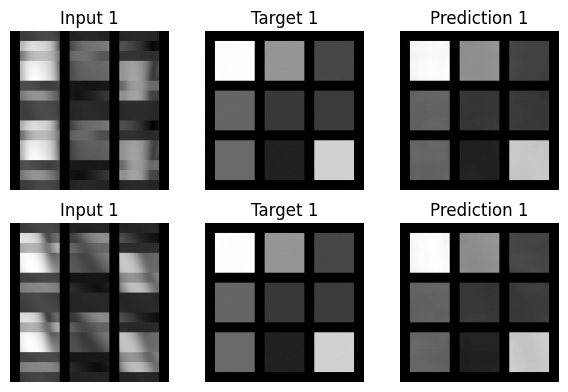

Target shape: (100, 128, 128), Prediction shape: (100, 128, 128)


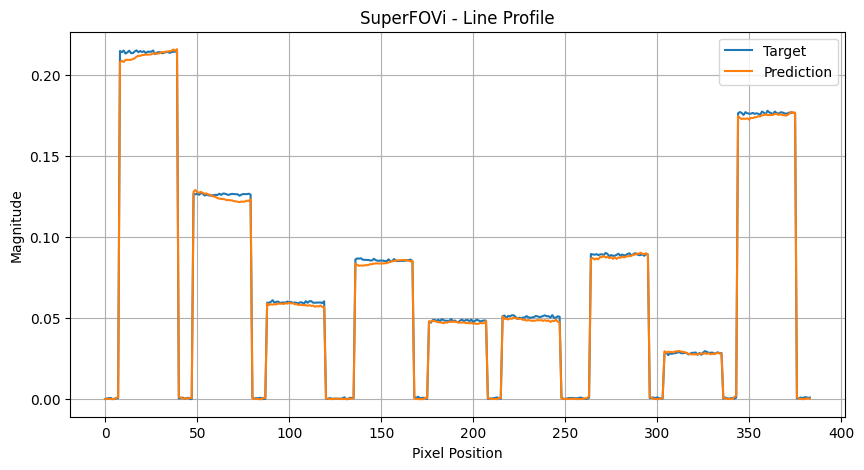


Evaluating band reduction...
Target shape: (100, 128, 128)
Prediction shape: (100, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
IDs to plot: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
Training history plot saved to D:/DeepSSFP/block9_phantom_superfovi_band_metrics_scatter


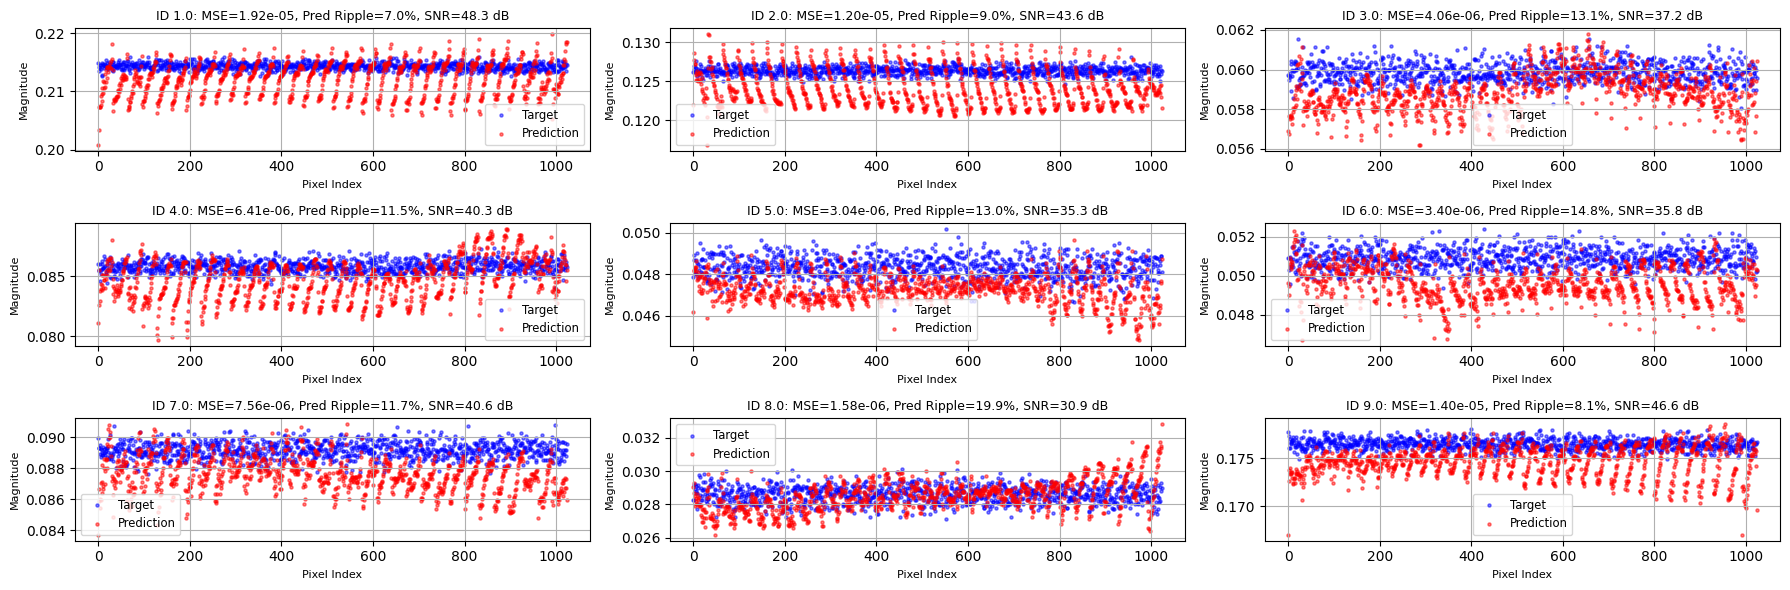

Training history plot saved to D:/DeepSSFP/block9_phantom_superfovi_band_metrics


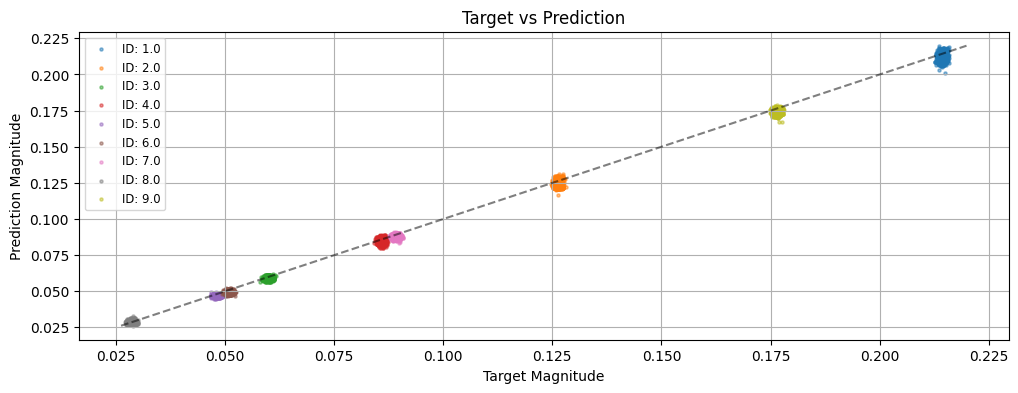


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=1.92e-05, MAE=3.48e-03, Pred Min=0.2034, Pred Max=0.2182, Pred Ripple=7.00%, Pred SNR=48.3 dB, Target Min=0.2124, Target Max=0.2162, Target Ripple=1.78%, Target SNR=49.4 dB, Samples=100, Pixels=1024
ID 2.0: MSE=1.20e-05, MAE=2.77e-03, Pred Min=0.1178, Pred Max=0.1290, Pred Ripple=9.04%, Pred SNR=43.6 dB, Target Min=0.1246, Target Max=0.1281, Target Ripple=2.72%, Target SNR=44.9 dB, Samples=100, Pixels=1024
ID 3.0: MSE=4.06e-06, MAE=1.63e-03, Pred Min=0.0553, Pred Max=0.0630, Pred Ripple=13.13%, Pred SNR=37.2 dB, Target Min=0.0582, Target Max=0.0615, Target Ripple=5.57%, Target SNR=38.4 dB, Samples=100, Pixels=1024
ID 4.0: MSE=6.41e-06, MAE=2.03e-03, Pred Min=0.0801, Pred Max=0.0898, Pred Ripple=11.49%, Pred SNR=40.3 dB, Target Min=0.0842, Target Max=0.0876, Target Ripple=3.91%, Target SNR=41.5 dB, Samples=100, Pixels=1024
ID 5.0: MSE=3.04e-06, MAE=1.39e-03, Pred Min=0.0447, Pred Max=0.0508, Pred Ripple=12.99%, Pred SNR=3

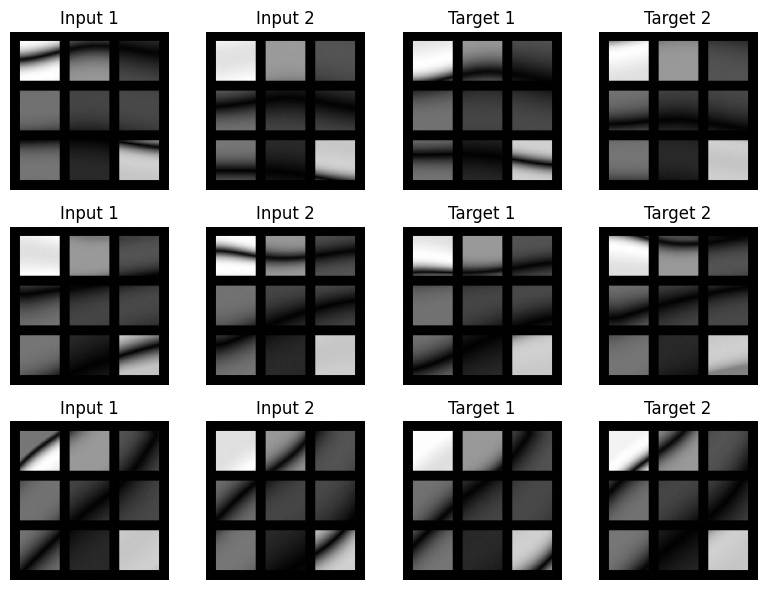

2025-03-26 22:34:49,235 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block9_phantom_syntheticbanding
2025-03-26 22:34:49,236 - DeepSSFP - INFO - Training DataSet: (400, 128, 128, 4) | (400, 128, 128, 4)
2025-03-26 22:34:49,236 - DeepSSFP - INFO - Test DataSet: (100, 128, 128, 4) | (100, 128, 128, 4)
2025-03-26 22:34:49,239 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x4→4



Training model...


2025-03-26 22:34:49,521 - DeepSSFP - INFO - Model created: unet


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 4) 0                                            
__________________________________________________________________________________________________
conv2d_57 (Conv2D)              (None, 128, 128, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_58 (Conv2D)              (None, 128, 128, 32) 9248        conv2d_57[0][0]                  
__________________________________________________________________________________________________
batch_normalization_27 (BatchNo (None, 128, 128, 32) 128         conv2d_58[0][0]                  
_______________________________________________________________________________________________

2025-03-26 22:43:23,820 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block9_phantom_syntheticbanding.keras


4/4 [==============================] - 0s 15ms/step - loss: 0.0061 - mean_absolute_error: 0.0276


2025-03-26 22:43:24,569 - DeepSSFP - INFO - Training Complete. Loss: 0.0061, MAE: 0.0276
2025-03-26 22:43:24,570 - DeepSSFP - INFO - Time Elapsed: 515.04 seconds
2025-03-26 22:43:25,725 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block9_phantom_syntheticbanding_training_history.png


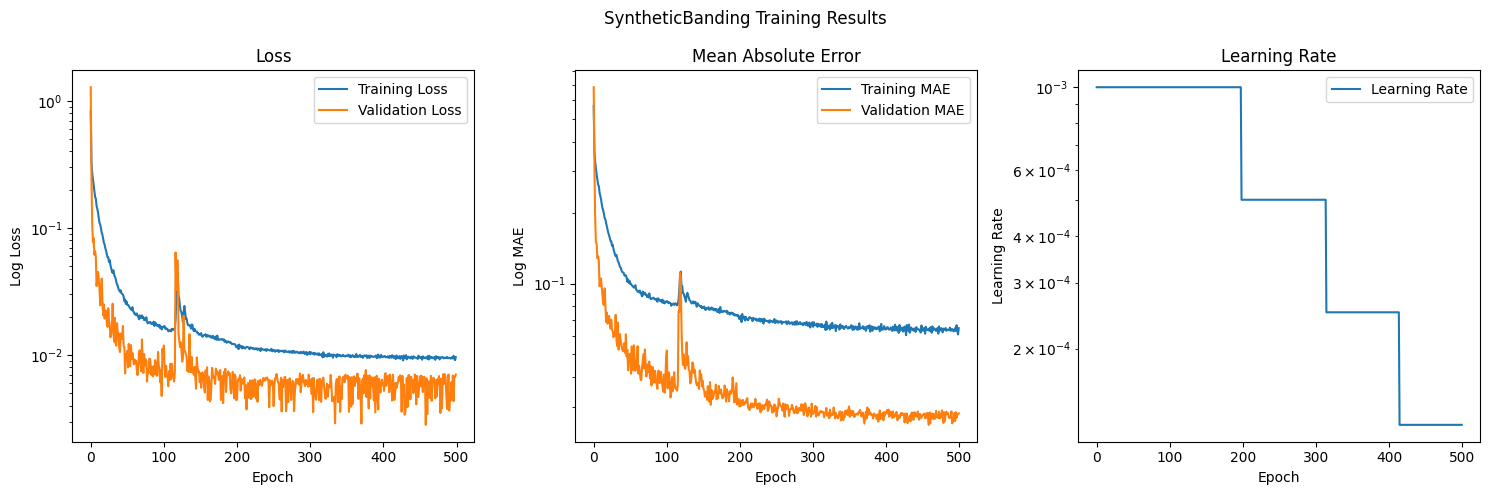

Using same scaler for SyntheticBanding mode


2025-03-26 22:43:28,191 - DeepSSFP - INFO - Making predictions on data with shape (100, 128, 128, 4)
2025-03-26 22:43:28,461 - DeepSSFP - INFO - Predictions complete. Output shape: (100, 128, 128, 4)


Selected indices: [ 1 34]
Figure size: (12, 4)
Image visualization saved to D:/DeepSSFP/block9_phantom_syntheticbanding_prediction_results.png


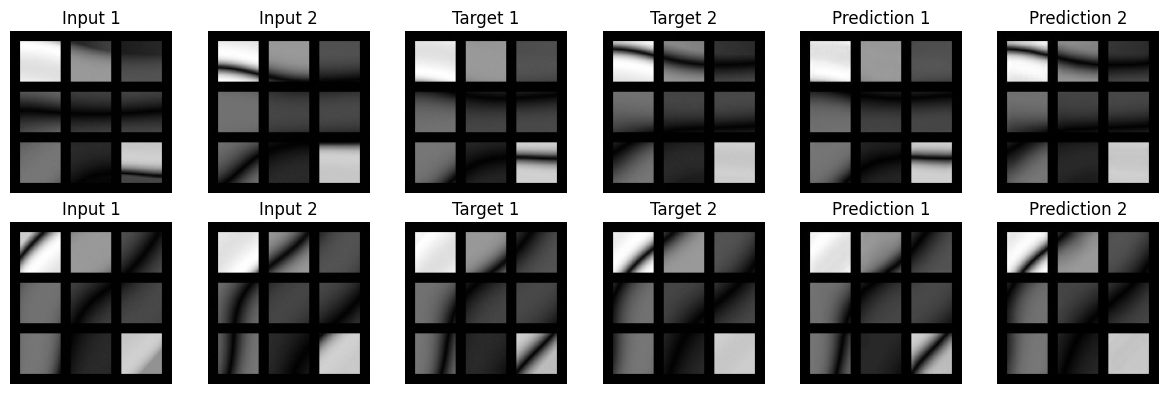

real/imag pairs -> complex
real/imag pairs -> complex
Target shape: (100, 128, 128), Prediction shape: (100, 128, 128)


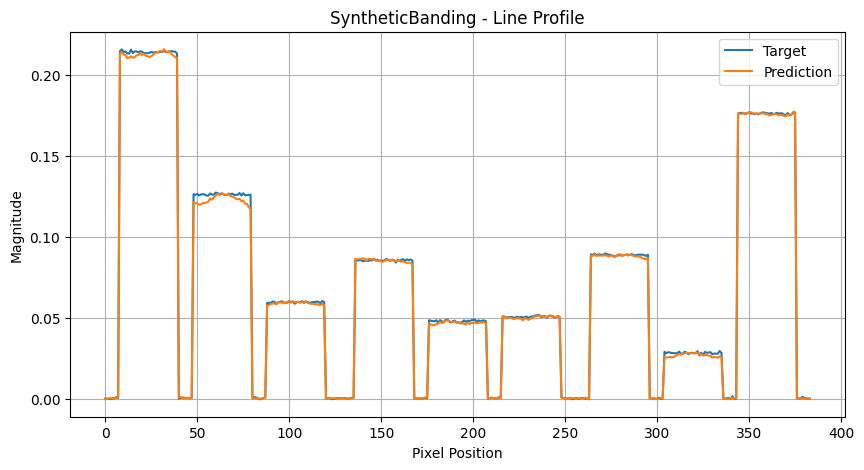


Evaluating band reduction...
Target shape: (100, 128, 128)
Prediction shape: (100, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
IDs to plot: [1. 2. 3. 4. 5. 6. 7. 8. 9.]
Training history plot saved to D:/DeepSSFP/block9_phantom_syntheticbanding_band_metrics_scatter


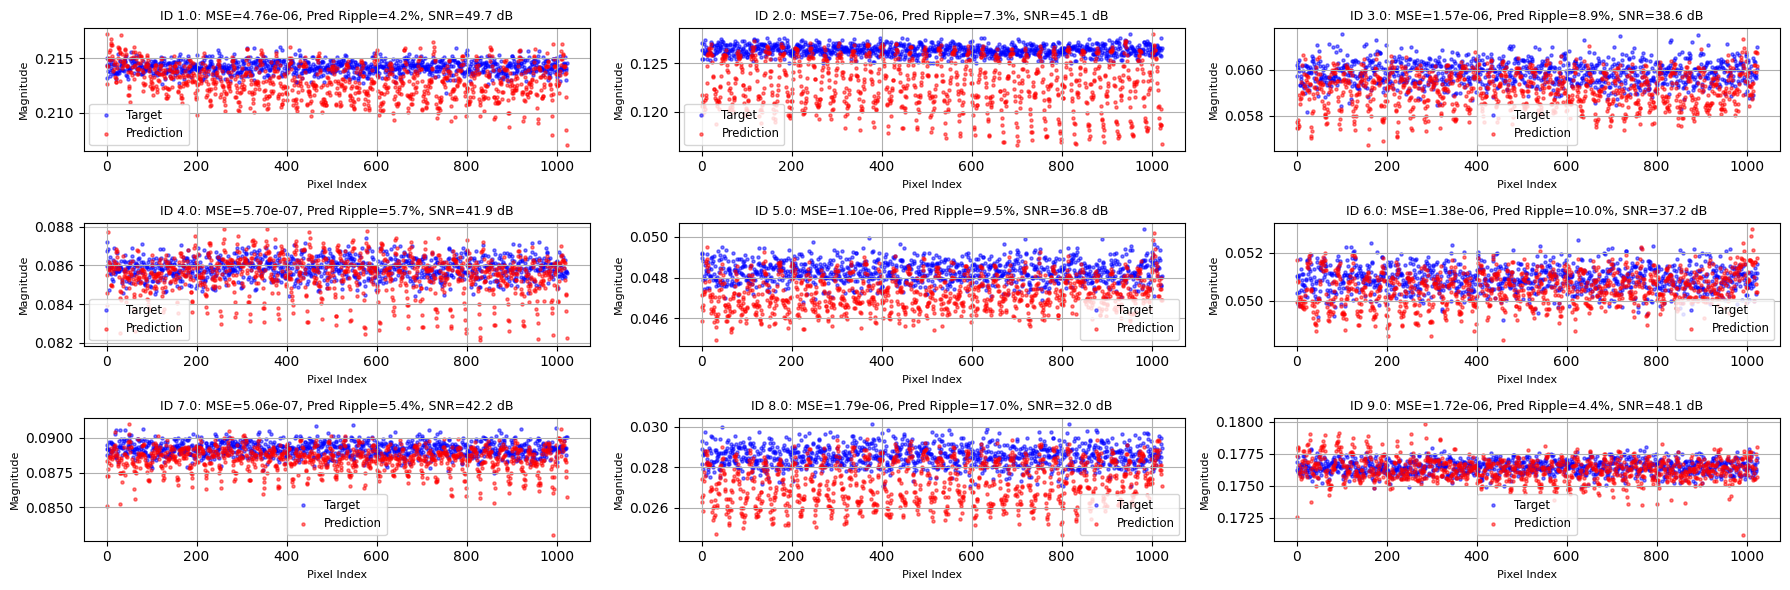

Training history plot saved to D:/DeepSSFP/block9_phantom_syntheticbanding_band_metrics


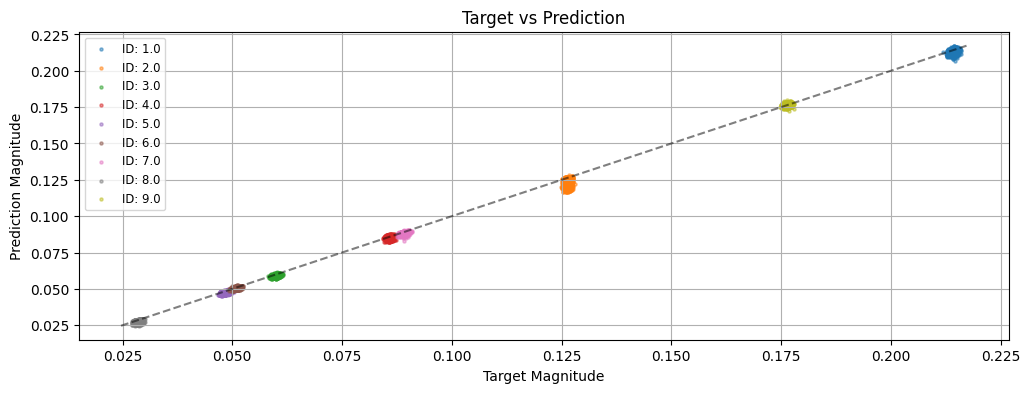


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=4.76e-06, MAE=1.74e-03, Pred Min=0.2083, Pred Max=0.2173, Pred Ripple=4.24%, Pred SNR=49.7 dB, Target Min=0.2124, Target Max=0.2163, Target Ripple=1.81%, Target SNR=49.4 dB, Samples=100, Pixels=1024
ID 2.0: MSE=7.75e-06, MAE=2.04e-03, Pred Min=0.1188, Pred Max=0.1279, Pred Ripple=7.34%, Pred SNR=45.1 dB, Target Min=0.1247, Target Max=0.1281, Target Ripple=2.74%, Target SNR=44.9 dB, Samples=100, Pixels=1024
ID 3.0: MSE=1.57e-06, MAE=9.60e-04, Pred Min=0.0560, Pred Max=0.0612, Pred Ripple=8.87%, Pred SNR=38.6 dB, Target Min=0.0582, Target Max=0.0615, Target Ripple=5.58%, Target SNR=38.4 dB, Samples=100, Pixels=1024
ID 4.0: MSE=5.70e-07, MAE=5.73e-04, Pred Min=0.0830, Pred Max=0.0879, Pred Ripple=5.74%, Pred SNR=41.9 dB, Target Min=0.0842, Target Max=0.0875, Target Ripple=3.85%, Target SNR=41.5 dB, Samples=100, Pixels=1024
ID 5.0: MSE=1.10e-06, MAE=7.80e-04, Pred Min=0.0453, Pred Max=0.0498, Pred Ripple=9.46%, Pred SNR=36.8

{'BandRemoval:4': {'mode': 'BandRemoval:4',
  'model': <tensorflow.python.keras.engine.functional.Functional at 0x1bf66ba7340>,
  'dataset': dataset.Dataset(BandRemoval:4),
  'predictions': array([[[ 1.36147696e-03-9.60812788e-04j,
           -5.85207134e-04+1.17232266e-04j,
            1.56904047e-04-9.09055234e-05j, ...,
            2.13649299e-04-6.95224153e-04j,
            1.47262297e-04+3.23793851e-04j,
            2.31154729e-04+1.16684684e-03j],
          [ 3.17332218e-04+3.98525444e-04j,
            1.17775449e-03+5.00443333e-04j,
            3.82884464e-04-2.67026713e-04j, ...,
           -5.98067709e-04-1.21164165e-04j,
            4.66510013e-04-8.63808440e-04j,
           -1.83766620e-04-4.67856386e-04j],
          [ 3.43331601e-04-4.39228548e-04j,
            4.60386800e-04+6.56090386e-04j,
            7.14122609e-04-2.84384994e-04j, ...,
            1.30205241e-04-3.72136798e-04j,
            6.90914632e-04-6.34324097e-04j,
            3.51621769e-04-1.25613093e-04j],
  

In [3]:
deepssfp.analysis.run_all_experiments(
    modes=modes,
    model_name=model_name,
    model_dir=model_dir,
    train_models=True, 
    #custom_dataset=dataset
)

In [4]:
# Compare experiment results
deepssfp.analysis.compare_experiments(
    modes=modes,
    model_name=model_name,
    model_dir=model_dir
)

Comparison plots saved to D:/DeepSSFP/block9_phantom_comparison_plots

===== Experiment Comparison Summary =====
Model: block9_phantom
Modes: BandRemoval:4, BandRemoval:2, SuperFOV, SuperFOVi, SyntheticBanding

Global Image Quality Metrics:
Metric  BandRemoval:4  BandRemoval:2  SuperFOV  SuperFOVi  SyntheticBanding
   MSE       0.000003       0.000003  0.000029   0.000005          0.000001
   MAE       0.001201       0.001092  0.004300   0.001390          0.000737
  PSNR      55.204080      55.410471 45.580276  53.669398         58.778417
  SSIM       0.999178       0.999313  0.961113   0.998964          0.999572
 NRMSE       0.020390       0.019857  0.062085   0.024652          0.013602

Best Mode by Metric:
  MSE: SyntheticBanding (0.000001)
  MAE: SyntheticBanding (0.000737)
  PSNR: SyntheticBanding (58.778417)
  SSIM: SyntheticBanding (0.999572)
  NRMSE: SyntheticBanding (0.013602)

Summary saved to D:/DeepSSFP//block9_phantom_metrics_summary.csv


<Figure size 1400x800 with 0 Axes>